<a href="https://colab.research.google.com/github/devanshijain-12/Tiger_Analytics_Assignment/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📊 Model Performance:
      Metric          Value
0       MAE  268856.572866
1      RMSE  333031.550247
2  MAPE (%)      18.741999
3        R2       0.319689


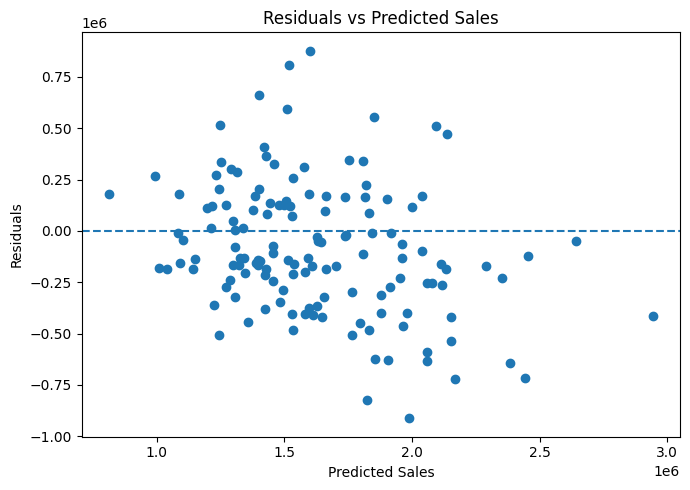


✅ Files saved:
 - /content/drive/MyDrive/Colab Notebooks/model_results_quick.xlsx
 - /content/drive/MyDrive/Colab Notebooks/residuals_quick.png


In [8]:
from google.colab import drive
import os

drive_path = "/content/drive"
if not os.path.ismount(drive_path):
    drive.mount(drive_path)

import warnings, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.tools import add_constant
import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore")

DATA_FILE="/content/drive/MyDrive/Colab Notebooks/DS Internship - Modeling - Data.xlsx"
TARGET_COL="Sales"
OUTPUT_EXCEL="/content/drive/MyDrive/Colab Notebooks/model_results_quick.xlsx"
RESID_PLOT="/content/drive/MyDrive/Colab Notebooks/residuals_quick.png"


# Load & Clean Data

df = pd.read_excel(DATA_FILE)

for col in df.columns:
    if "id" in col.lower():
        df = df.drop(columns=col)

for c in df.select_dtypes(include=["object"]).columns:
    try:
        new = pd.to_numeric(df[c].astype(str).str.replace(",", "").str.strip(), errors="coerce")
        if new.notna().sum() > 0.5 * len(df):
            df[c] = new
    except:
        pass

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
num_cols = [c for c in num_cols if c != TARGET_COL]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0] if not df[c].mode().empty else "Missing").astype(str)

df = df.dropna(subset=[TARGET_COL])
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_enc.drop(columns=[TARGET_COL])
y = df_enc[TARGET_COL].astype(float)

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)


# OLS Model

final_model = sm.OLS(y_train, add_constant(X_train)).fit()
X_test_const = add_constant(X_test)
y_pred = final_model.predict(X_test_const)


# Metrics

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae = mean_absolute_error(y_test, y_pred)

try:
    rmse = mean_squared_error(y_test, y_pred, squared=False)  # new sklearn
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # fallback for old sklearn

mape_val = mape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)", "R2"],
    "Value": [mae, rmse, mape_val, r2]
})
print("\n📊 Model Performance:\n", metrics)


# Residual Plot

residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales")
plt.tight_layout()
plt.show()
plt.savefig(RESID_PLOT)
plt.close()


# Save Results

coef_df = pd.DataFrame({
    "Feature": final_model.params.index,
    "Coefficient": final_model.params,
    "P-Value": final_model.pvalues
}).reset_index(drop=True)

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    coef_df.to_excel(writer, sheet_name="Coefficients", index=False)
    metrics.to_excel(writer, sheet_name="Performance", index=False)
    pd.DataFrame({"summary": final_model.summary().as_text().splitlines()}).to_excel(
        writer, sheet_name="Model_Summary", index=False
    )

print("\n✅ Files saved:")
print(" -", OUTPUT_EXCEL)
print(" -", RESID_PLOT)
